In [35]:
from astropy.table import Table
from astropy import units as u
from astropy.constants import c

import matplotlib as mpl
import matplotlib.pyplot as plt

from scipy.optimize import minimize

import numpy as np

import numdifftools as ndt

In [36]:
loa_rotvel = Table.read('/pscratch/sd/d/dbustos/rot_curves/loa_rot_velocity.fits')
loa_rotvel[:5]

TARGETID,SGA_ID,TARGET_RA,TARGET_DEC,Z,Z_RR,ZWARN,DELTACHI2,DIST,DIST_R26,PA,C_TO_F_ANGLE,ANGLE_OFF_AXIS,Selection,ZERR_MOD,unique_obs,Velocity,V_err,Z_center,VI,deproj_dist,deproj_r26,manual_VI
int64,int64,float64,float64,float64,float64,int64,float64,float64,float64,float64,float64,float64,int64,float64,float64,float64,float64,float64,int64,float64,float64,int64
6521555517440,1157225,204.22749,32.09493,0.010016011261740405,0.010016011261740405,0,71.96394567680545,0.002217102021260331,0.36627155666222244,65.12960815429688,114.35180431415512,49.22219615985824,1,2.358335538525183e-05,3.0,-6.4195914543075165,13.76801200779403,2.358358388059241e-05,0,0.002881332554681444,0.4760043290496788,0
169678387281926,1430874,257.7495971,56.9324928,0.028921517883227336,0.028921517883227336,0,121857.89663615823,0.003250448915035935,0.31250071154567677,6.557606220245361,206.22810010342067,199.6704938831753,1,2.4024789259983957e-05,3.0,182.8750198451699,11.489101308260244,2.401212431981059e-05,0,0.008096415535868652,0.7783957484224773,0
243323033878571,631434,151.0147419137485,1.6331543609904198,1.3809988331159857,1.3809988331159857,4,0.7242707014083862,0.0057124407591539585,0.9175586924842383,51.69132614135742,32.48938717521324,19.201938966144183,1,5.5595100500533275e-05,8.0,472239.65646196203,24.11477245431036,1.7258340278094598e-05,0,0.006601088916040368,1.0602974753074295,0
1004815400304641,188925,193.6701,28.93758,0.0082724267277799,0.0082724267277799,0,20781.262633197082,0.0009923137447555642,0.026284859154548004,48.5860481262207,146.26021571620655,97.67416758998584,2,2.3542643581428787e-05,31.0,-181.63274387448345,72.81809787647651,1.6648346838273807e-05,0,0.0011151277859353821,0.02953801350383857,0
1005093910478848,1309576,234.30175,43.3014166667,0.019607169071382585,0.019607169071382585,0,21025.242969959974,0.004020441905483598,0.2179634595949638,134.6117401123047,320.7967839323471,186.18504382004244,1,2.380730399661915e-05,8.0,173.70559603525007,12.904304444072334,2.3796769180937358e-05,0,0.005374691904048404,0.2913825069989467,0


In [37]:
SGA = Table.read('/global/cfs/cdirs/cosmo/data/sga/2020/SGA-2020.fits', 'ELLIPSE')
SGA[:5]

SGA_ID,SGA_GALAXY,GALAXY,PGC,RA_LEDA,DEC_LEDA,MORPHTYPE,PA_LEDA,D25_LEDA,BA_LEDA,Z_LEDA,SB_D25_LEDA,MAG_LEDA,BYHAND,REF,GROUP_ID,GROUP_NAME,GROUP_MULT,GROUP_PRIMARY,GROUP_RA,GROUP_DEC,GROUP_DIAMETER,BRICKNAME,RA,DEC,D26,D26_REF,PA,BA,RA_MOMENT,DEC_MOMENT,SMA_MOMENT,G_SMA50,R_SMA50,Z_SMA50,SMA_SB22,SMA_SB22.5,SMA_SB23,SMA_SB23.5,SMA_SB24,SMA_SB24.5,SMA_SB25,SMA_SB25.5,SMA_SB26,G_MAG_SB22,R_MAG_SB22,Z_MAG_SB22,G_MAG_SB22.5,R_MAG_SB22.5,Z_MAG_SB22.5,G_MAG_SB23,R_MAG_SB23,Z_MAG_SB23,G_MAG_SB23.5,R_MAG_SB23.5,Z_MAG_SB23.5,G_MAG_SB24,R_MAG_SB24,Z_MAG_SB24,G_MAG_SB24.5,R_MAG_SB24.5,Z_MAG_SB24.5,G_MAG_SB25,R_MAG_SB25,Z_MAG_SB25,G_MAG_SB25.5,R_MAG_SB25.5,Z_MAG_SB25.5,G_MAG_SB26,R_MAG_SB26,Z_MAG_SB26,SMA_SB22_ERR,SMA_SB22.5_ERR,SMA_SB23_ERR,SMA_SB23.5_ERR,SMA_SB24_ERR,SMA_SB24.5_ERR,SMA_SB25_ERR,SMA_SB25.5_ERR,SMA_SB26_ERR,G_MAG_SB22_ERR,R_MAG_SB22_ERR,Z_MAG_SB22_ERR,G_MAG_SB22.5_ERR,R_MAG_SB22.5_ERR,Z_MAG_SB22.5_ERR,G_MAG_SB23_ERR,R_MAG_SB23_ERR,Z_MAG_SB23_ERR,G_MAG_SB23.5_ERR,R_MAG_SB23.5_ERR,Z_MAG_SB23.5_ERR,G_MAG_SB24_ERR,R_MAG_SB24_ERR,Z_MAG_SB24_ERR,G_MAG_SB24.5_ERR,R_MAG_SB24.5_ERR,Z_MAG_SB24.5_ERR,G_MAG_SB25_ERR,R_MAG_SB25_ERR,Z_MAG_SB25_ERR,G_MAG_SB25.5_ERR,R_MAG_SB25.5_ERR,Z_MAG_SB25.5_ERR,G_MAG_SB26_ERR,R_MAG_SB26_ERR,Z_MAG_SB26_ERR,G_COG_PARAMS_MTOT,G_COG_PARAMS_M0,G_COG_PARAMS_ALPHA1,G_COG_PARAMS_ALPHA2,G_COG_PARAMS_CHI2,R_COG_PARAMS_MTOT,R_COG_PARAMS_M0,R_COG_PARAMS_ALPHA1,R_COG_PARAMS_ALPHA2,R_COG_PARAMS_CHI2,Z_COG_PARAMS_MTOT,Z_COG_PARAMS_M0,Z_COG_PARAMS_ALPHA1,Z_COG_PARAMS_ALPHA2,Z_COG_PARAMS_CHI2,ELLIPSEBIT
int64,bytes16,bytes29,int64,float64,float64,bytes21,float32,float32,float32,float32,float32,float32,bool,bytes13,int64,bytes35,int16,bool,float64,float64,float32,bytes8,float64,float64,float32,bytes4,float32,float32,float64,float64,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,int32
2,SGA-2020 2,PGC1283207,1283207,228.3770865,5.4232017,S?,152.2,0.36307806,0.724436,0.03463229,23.40448,16.976,False,LEDA-20181114,0,PGC1283207,1,True,228.3770865,5.4232017,0.36307806,2283p055,228.3770803831908,5.423191398593787,0.49470574,SB26,158.20142,0.545691,228.37700918822188,5.4232652570544015,10.897086,3.3509698,3.1147978,3.240862,5.902337,6.9126143,7.941369,8.997992,10.073601,11.199986,12.391357,13.561038,14.841172,16.966799,16.108246,15.486356,16.879545,16.024958,15.400715,16.818878,15.967034,15.341793,16.776297,15.925804,15.300776,16.746685,15.897334,15.272053,16.725166,15.876816,15.2521105,16.708357,15.862035,15.237181,16.696539,15.851936,15.226998,16.689613,15.844313,15.21976,0.013392451,0.02354,0.021872982,0.01736985,0.024445537,0.039866067,0.05026544,0.08455789,0.122911856,0.005682776,0.0054258136,0.0049038026,0.005588406,0.005323561,0.0047632363,0.00543534,0.005177031,0.0046343105,0.0053025587,0.005040888,0.0045181247,0.005206092,0.0049438984,0.0044374703,0.0051483097,0.0048758644,0.0043834248,0.0051032505,0.0048264163,0.004344248,0.0050705094,0.004792021,0.004319857,0.005054293,0.004765629,0.0043044444,16.65942,0.34037337,0.2978292,3.0239506,0.07928849,15.820566,0.2640441,0.34559453,3.3033552,0.003811298,15.195567,0.29826432,0.3001073,3.2333765,0.011723555,0
3,SGA-2020 3,PGC1310416,1310416,202.54443750000002,6.9345944,Sc,159.26,0.4017908,0.7816278,0.073888786,23.498482,16.85,False,LEDA-20181114,1,PGC1310416,1,True,202.54443750000002,6.9345944,0.4017908,

In [38]:
SGA_dict = {}
for i in range(len(SGA)):
    SGA_dict[SGA['SGA_ID'][i]] = i

## get distance from center to fiber in kpc/h

In [39]:
#Reduced Hubble Constant (km/s/Mpc)
H0 = 100 * u.km / u.s / u.Mpc

#c in km/s
c = c.to('km/s')

In [ ]:
loa_rotvel['r_kpc']= np.nan

for i in np.unique(loa_rotvel['SGA_ID']):

    targ_id = loa_rotvel['SGA_ID'] == i

    sga_id = SGA_dict[i]

    # distance from us to center of galaxy
    d_center = (SGA['Z_LEDA'][sga_id] * c)/H0

    # convert deprojected dist from arcmin to radians
    theta = np.radians((loa_rotvel['deproj_dist'][targ_id])/60)

    # real distance from center of galaxy to fiber in units kpc/h
    r_fiber = d_center * np.tan(theta) * 1000

    loa_rotvel['r_kpc'][targ_id]=abs(r_fiber)

#z = loa_rotvel['Z'][targ_id]    
#distance from us to fiber location
#d_fiber = (z * c)/H0
#r_fiber = d_fiber * np.tan(theta) * 1000

In [30]:
loa_rotvel[:5]

TARGETID,SGA_ID,TARGET_RA,TARGET_DEC,Z,Z_ERR,ZWARN,DELTACHI2,DIST,DIST_R26,PA,C_TO_F_ANGLE,ANGLE_OFF_AXIS,Selection,ZERR_MOD,unique_obs,Velocity,V_err,Z_center,VI,deproj_dist,deproj_r26,manual_VI,r_kpc
int64,int64,float64,float64,float64,float64,int64,float64,float64,float64,float64,float64,float64,int64,float64,float64,float64,float64,float64,int64,float64,float64,int64,float64
6521555517440,1157225,204.22749,32.09493,0.010016011261740405,0.010016011261740405,0,71.96394567680545,0.002217102021260331,0.36627155666222244,65.12960815429688,114.35180431415512,49.22219615985824,1,0.010016039025980373,3.0,-4.192810421175031,6132.828833328053,0.010025824882245725,0,0.002881332554681444,0.4760043290496788,0,0.025193817885168415
67815440646152,993764,131.54147036553024,19.348963933595506,0.6888593799981794,0.6888593799981794,4,7.544203393161297,0.004898285806031614,0.44172182227817786,9.1672945022583,188.95042393619124,179.78312943393294,1,0.688859381126886,3.0,241229.26197007135,250163.33365325944,0.014690024421240906,0,0.00677902926522777,0.6113251204383032,0,0.08665293728548588
169678387281926,1430874,257.7495971,56.9324928,0.028921517883227336,0.028921517883227336,0,121857.89663615823,0.003250448915035935,0.31250071154567677,6.557606220245361,206.22810010342067,199.6704938831753,1,0.02892152786179073,3.0,172.20316827862342,13229.169233269766,0.028379120392506063,0,0.008096415535868652,0.7783957484224773,0,0.20122416188287864
234526940856326,5001181,151.1772061023157,1.833743864948717,0.03108437229025544,0.03108437229025544,0,13100.219412088394,0.001016580293940661,0.34937980530094326,107.75557708740234,118.54239042958262,10.786813342180281,1,0.031084381613582526,4.0,21.663640864728954,12008.077317045758,0.021929943091409377,0,0.0031839814928551905,1.0942754258430336,0,2.7766258006022113
234563162865665,632204,150.23137029728193,3.151162371010314,1.2707527411865653,1.2707527411865653,4,1.0103464424610138,0.011775468159487008,0.8630857807133053,159.4539031982422,322.60583622868717,163.15193303044498,1,1.270752742292688,23.0,381811.2817196457,402319.7942284944,0.020711037186530452,0,0.013838610970700105,1.014304330992709,1,0.35324467520432595


In [23]:
# Save new table w/ r_kpc
loa_rotvel.write('/pscratch/sd/d/dbustos/rot_curves/loa_rotvel_rkpc.fits',format='fits',overwrite=True)

## Plot v vs r and add curve fit

In [11]:
# def v_rot(r, v_max, r_turn, a):
#     return (v_max * r)/((r_turn**a + r**a)**(1/a))

def v_rot(r, v_max, r_turn):
    return (v_max) * np.tanh(r/r_turn)

In [12]:
# def chi2(params, v_data, v_err, r):
#     v_max, r_turn, a = params
#     v_model = (v_max * r)/((r_turn**a + r**a)**(1/a))
#     return np.sum(((v_data-v_model)/v_err)**2)

def chi2(params, v_data, v_err, r):
    v_max, r_turn = params
    v_model = (v_max) * np.tanh(r/r_turn)
    return np.sum(((v_data-v_model)/v_err)**2)

In [13]:
# reduced chi 2 = chi 2 / (number of data points - number of free parameters)
def chi2_reduced(chi2, num_data):
    num_params = 2
    dof = num_data - num_params
    return chi2/dof

In [31]:
loa_rotvel['chi2_reduced'] = np.nan
loa_rotvel['vmax_fit'] = np.nan
loa_rotvel['rturn_fit'] = np.nan
loa_rotvel['alpha_fit'] = np.nan

In [34]:
for i in np.unique(loa_rotvel['SGA_ID'])[:50]:

    sga_id = i
    
    targ_id = loa_rotvel[loa_rotvel['SGA_ID'] == sga_id]

    # grab all fibers with velocity < 1000 km/s and passed VI
    valid_fibers = targ_id[(abs(targ_id['Velocity'])<1000) & (targ_id['V_err']>0)]
    
    # grab radius
    r_kpc = valid_fibers['r_kpc']
    
    # make sure there are still 3 points to curve fit
    if (len(valid_fibers) < 3) or (len(np.unique(r_kpc.round(5))) < 3):
        continue

    # absolute velocities
    velocity = abs(valid_fibers['Velocity'])

    v_err = valid_fibers['V_err']

    # normalize r
    idx = np.argmax(velocity)

    r26_ratio = valid_fibers['DIST_R26']
    r26 = r_kpc[idx]/r26_ratio[idx]
    
#----------------------------------------------------------------------------
#create a pseudo-center fiber if there isn't one to assist with curve fitting
#----------------------------------------------------------------------------

    if np.all(r_kpc) != 0:
        z_cen_err = valid_fibers['Z_center'][0]
        velocity = np.append(velocity,0)
        r_kpc = np.append(r_kpc,0)
        v_err = np.append(v_err,c*z_cen_err)


#-----------------------------------------
# curve fitting
#-----------------------------------------
     
    # bounds for v max, r turn
    bounds = [(0,1000),(0.01,np.max(r_kpc))]

    # initial guess for v max, r turn
    initial_guess = [velocity[idx], r_kpc[idx]]

    #-------------
    # curve fit ----------------------------------
    #-------------
    min_fxn = minimize(fun = chi2, 
                 x0 = initial_guess, 
                 args = (velocity, v_err, r_kpc), 
                 bounds = bounds, 
                 method = 'Powell')
    #---------------------------------------------
    
    # vmax_fit, rturn_fit, alpha_fit
    min_fits = min_fxn.x
    
    #--------------------
    # get reduced chi 2 -------------------------------
    #--------------------
    chi2_fit= min_fxn.fun
    
    data_pts = len(velocity)
    
    reduced_chi2 = chi2_reduced(chi2_fit, data_pts)
    #------------------------------------------------
    
    

#-------------------------------
# uncertainty from curve fit
#-------------------------------
    
    hessian = ndt.Hessian(chi2)
    hess = hessian(min_fits,velocity, v_err, r_kpc)

    # get covariance matrix for errors
    # make empty matrix of nans to prevent from plotting
    try:
    #covariance matrix
        hess_inv = 2*np.linalg.inv(hess)
    # vmax_err, rturn_err, alpha_err
        fit_params_err = np.sqrt(np.diag(np.abs(hess_inv)))
    
    except np.linalg.LinAlgError:
        # Do an alternate to the above
        hess_inv = np.full((2,2),np.nan)

        
        
#----------------
# plot
#----------------
    fig = plt.figure()
    ax = fig.add_subplot()

    #---------------
    # curve fit -------------------------------------------
    #---------------
    r1 = np.linspace(0,r26,500)

    v_r = v_rot(r1,min_fits[0],min_fits[1])
    #------------------------------------------------------

    # sample size
    size = 1000
    
    #------------------------------
    # uncertainty on curve fit   ---------------------------------------------------------------
    #------------------------------
    if ~np.isnan(hess_inv).any():
        samples=np.random.multivariate_normal(min_fits,hess_inv,size=size)

        # make sure all samples are positive
        good_samples = samples[(samples > 0).all(axis = 1)]
    
        # empty array for sample curve fit to go in
        v_sample = np.zeros((len(good_samples),500))
        
        # get curve fit for each sample distribution
        for i in range(len(good_samples)):
            indx = samples[i]
            v_x = v_rot(r1, indx[0], indx[1])
            v_sample[i] = v_x
        
        #take standard deviation for all v_rot along each r
        std_dev = np.std(v_sample[~np.isnan(v_sample).any(axis=1)], axis = 0)

        # plot uncertainty
        ax.fill_between(r1/r26, v_r - std_dev, v_r + std_dev, alpha = .12, color = 'chartreuse')
        
        # plot curve fit
        ax.plot(r1/r26, v_r, color = 'mediumseagreen', zorder =1 )
        
    else:
        # plot curve fit
        ax.plot(r1/r26, v_r, color = 'mediumseagreen', zorder = 1)
        
        # note the covariance matrix returned NAN
        ax.annotate('invalid hessian', xy = (10,10), xycoords = 'figure pixels')
    #------------------------------------------------------------------------------------------------

    
    

    #------------------------------
    # v vs r points and errorbars -------------------------------------------------------------------------------------
    #------------------------------
    ax.errorbar(r_kpc/r26, velocity, yerr = v_err, ls = 'none', ecolor = 'xkcd:lighter purple', capsize = 5, zorder=2, alpha = .6)
    ax.scatter(r_kpc/r26, velocity, c = 'xkcd:vivid purple', zorder = 3)
    # ------------------------------------------------------------------------------------------------------------------
    
    ax.grid(ls=':')
    ax.set_title('SGA ID: {}'.format(sga_id))
    ax.set_xlim(None, 1.01)
    ax.set_ylim(0, None)
    ax.set(xlabel='$r/R_{26}$', ylabel='$v_{rot}$ $($ $km/s$ $)$')

    
    
#-----------------------------------------  
# save everything to table or $PSCRATCH
#----------------------------------------- 
    
    # fig.savefig('/pscratch/sd/d/dbustos/curve_fit/' + 'sga_{}_curve_fit.png'.format(sga_id), dpi=120)
    
    # fig.clear()
    # plt.close(fig)
    
    # np.save('/pscratch/sd/d/dbustos/hessian/' + str(sga_id) + '_hessian.npy', hess)
    
    # table_idx = (loa_rotvel['SGA_ID'] == sga_id) & ((abs(loa_rotvel['Velocity']) < 1000)) & (loa_rotvel['bad_map']==0)
    # loa_rotvel['chi2_reduced'][table_idx] = reduced_chi2

    # loa_rotvel['vmax_fit'][table_idx] = min_fxn[0]
    # loa_rotvel['rturn_fit'][table_idx] = min_fxn[1]
    # loa_rotvel['alpha_fit'][table_idx] = min_fxn[2]
    
    # sanity check ---------------------------------
    print('sga_id:',str(sga_id))
    print('minimize fits (v, r): ', min_fits)
    print('fit_params_err (v, r): ', fit_params_err)
    print('reduced chi2: ', reduced_chi2)

KeyError: 'r_kpc'

sga_id: 425
minimize fits (v, r):  [50.0780436  22.21380428]
fit_params_err (v, r):  [382.82731059 307.10108874]
reduced chi2:  0.002056455260116496
sga_id: 7880
minimize fits (v, r):  [131.34989961   2.74710459]
fit_params_err (v, r):  [56.79985019  1.33598004]
reduced chi2:  3.069002461049568
sga_id: 12657
minimize fits (v, r):  [95.08592707  0.39826083]
fit_params_err (v, r):  [56.79985019  1.33598004]
reduced chi2:  0.0014165510184865277
sga_id: 31124
minimize fits (v, r):  [108.70152825   1.11689772]
fit_params_err (v, r):  [10.53904895  0.74487882]
reduced chi2:  0.022928060318178914
sga_id: 36792
minimize fits (v, r):  [157.0606721    2.25290217]
fit_params_err (v, r):  [41.10379723  1.08093634]
reduced chi2:  0.03237716818697054
sga_id: 37670
minimize fits (v, r):  [34.78932861 10.45647794]
fit_params_err (v, r):  [72.66856338 71.01822017]
reduced chi2:  0.047616933710666345
sga_id: 52700
minimize fits (v, r):  [678.78614611   1.42648072]
fit_params_err (v, r):  [19.37253564  0

/tmp/ipykernel_194751/2578383141.py:116: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  samples=np.random.multivariate_normal(min_fits,hess_inv,size=size)
/tmp/ipykernel_194751/2578383141.py:116: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  samples=np.random.multivariate_normal(min_fits,hess_inv,size=size)
/tmp/ipykernel_194751/2578383141.py:116: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  samples=np.random.multivariate_normal(min_fits,hess_inv,size=size)


sga_id: 53411
minimize fits (v, r):  [48.37487464 15.03351375]
fit_params_err (v, r):  [329.45031247 184.8769913 ]
reduced chi2:  6.986279453467802e-05
sga_id: 59456
minimize fits (v, r):  [6.02554358e+01 1.00263074e-02]
fit_params_err (v, r):  [8.33878714 0.33943531]
reduced chi2:  0.047260048478214606
sga_id: 91888
minimize fits (v, r):  [197.13558355  25.27232444]
fit_params_err (v, r):  [528.3006721  122.96077901]
reduced chi2:  0.0886175233371282
sga_id: 99063
minimize fits (v, r):  [1.17568939e+02 2.99937531e-02]
fit_params_err (v, r):  [4.80275194 0.132366  ]
reduced chi2:  0.2736746501896738


/tmp/ipykernel_194751/2578383141.py:116: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  samples=np.random.multivariate_normal(min_fits,hess_inv,size=size)


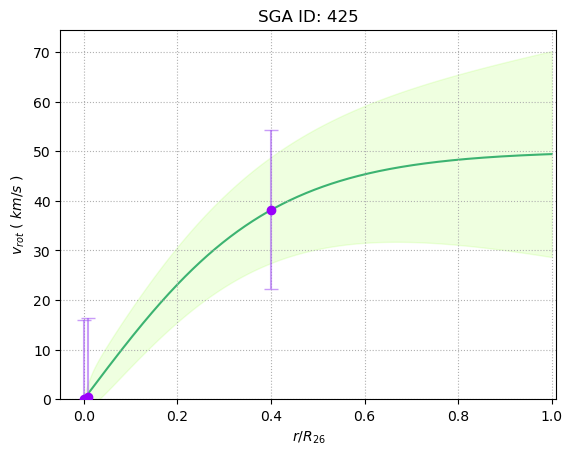

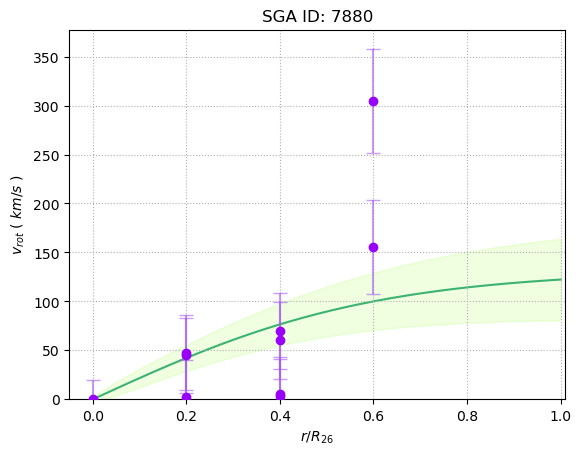

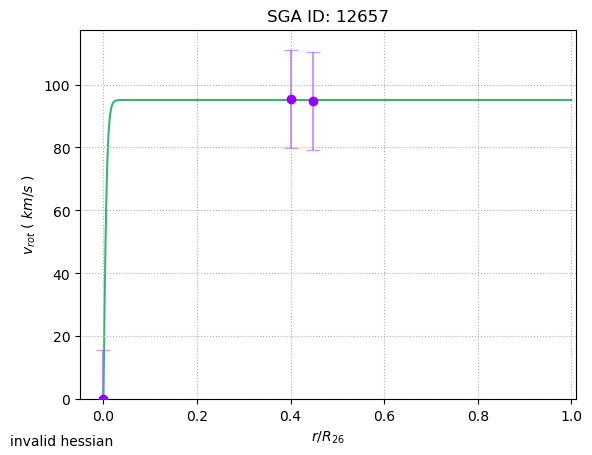

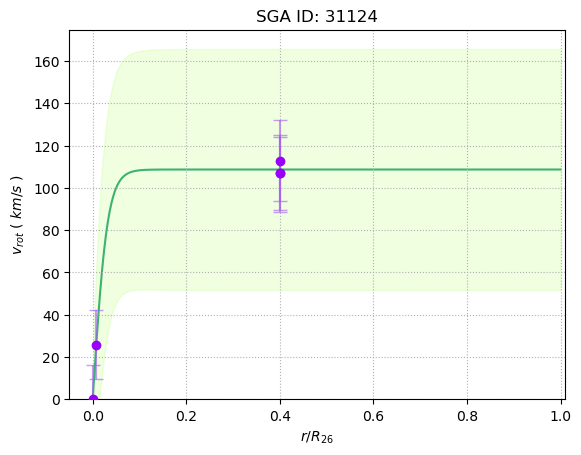

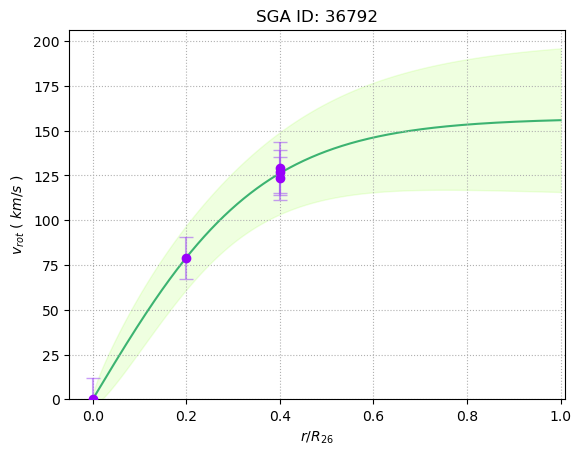

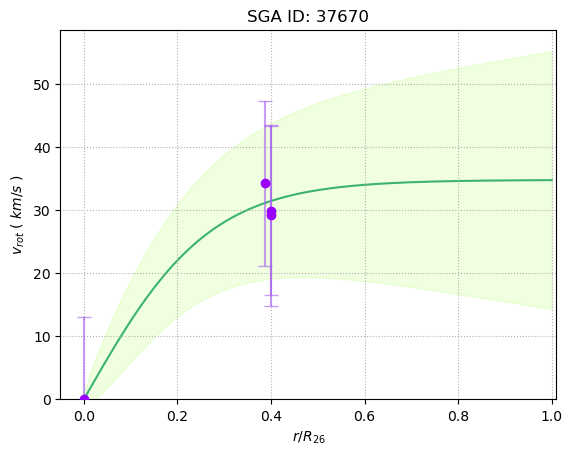

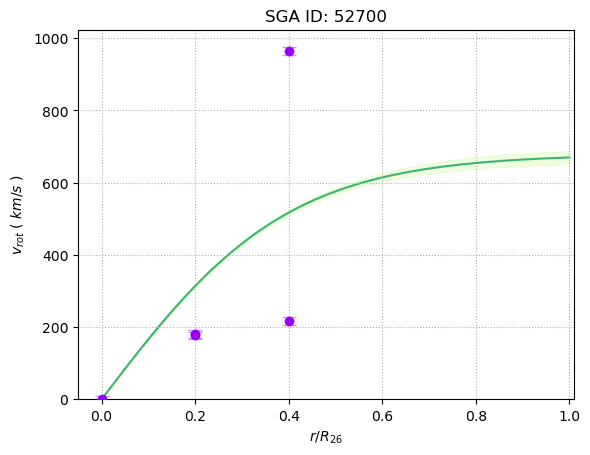

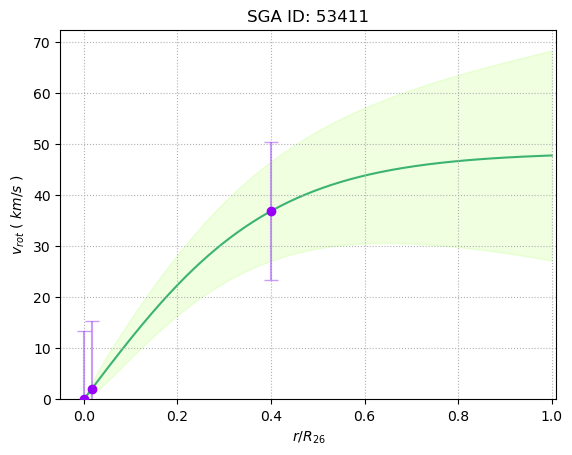

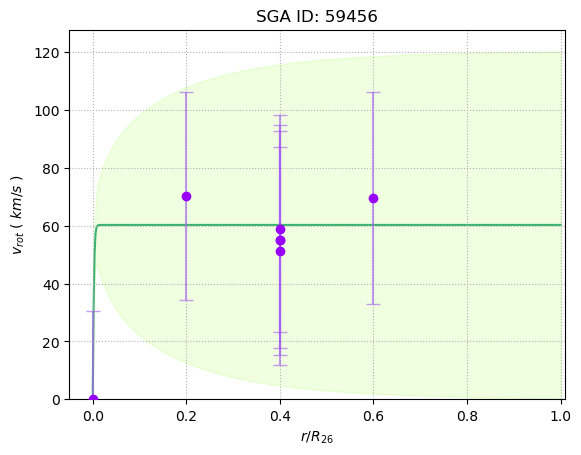

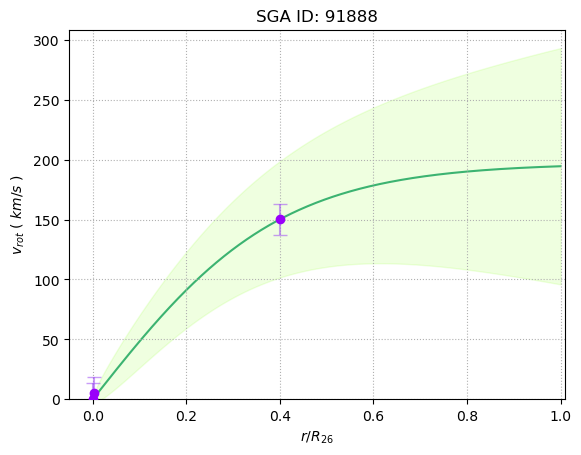

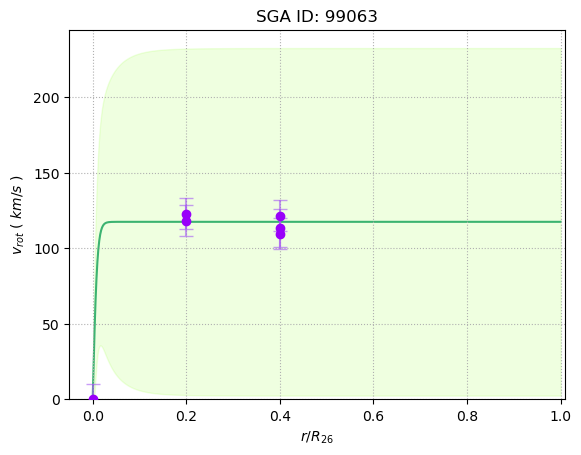

In [11]:
for i in np.unique(loa_rotvel['SGA_ID'])[:50]:

    sga_id = i
    
    targ_id = loa_rotvel[loa_rotvel['SGA_ID'] == sga_id]

    # grab all fibers with velocity < 1000 km/s and passed VI
    valid_fibers = targ_id[(abs(targ_id['Velocity'])<1000) & (targ_id['bad_map']==0)]
    
    # grab radius
    r_kpc = valid_fibers['r_kpc']
    
    # make sure there are still 3 points to curve fit
    if (len(valid_fibers) < 3) or (len(np.unique(r_kpc.round(5))) < 3):
        continue

    # absolute velocities
    velocity = abs(valid_fibers['Velocity'])

    v_err = valid_fibers['V_err']

    # normalize r
    idx = np.argmax(velocity)

    r26_ratio = valid_fibers['DIST_R26']
    r26 = r_kpc[idx]/r26_ratio[idx]
    
#----------------------------------------------------------------------------
#create a pseudo-center fiber if there isn't one to assist with curve fitting
#----------------------------------------------------------------------------

    if np.all(r_kpc) != 0:
        z_cen_err = valid_fibers['Z_center'][0]
        velocity = np.append(velocity,0)
        r_kpc = np.append(r_kpc,0)
        v_err = np.append(v_err,c*z_cen_err)


#-----------------------------------------
# curve fitting
#-----------------------------------------
     
    # bounds for v max, r turn
    bounds = [(0,1000),(0.01,np.max(r_kpc))]

    # initial guess for v max, r turn
    initial_guess = [velocity[idx], r_kpc[idx]]

    #-------------
    # curve fit ----------------------------------
    #-------------
    min_fxn = minimize(fun = chi2, 
                 x0 = initial_guess, 
                 args = (velocity, v_err, r_kpc), 
                 bounds = bounds, 
                 method = 'Powell')
    #---------------------------------------------
    
    # vmax_fit, rturn_fit, alpha_fit
    min_fits = min_fxn.x
    
    #--------------------
    # get reduced chi 2 -------------------------------
    #--------------------
    chi2_fit= min_fxn.fun
    
    data_pts = len(velocity)
    
    reduced_chi2 = chi2_reduced(chi2_fit, data_pts)
    #------------------------------------------------
    
    

#-------------------------------
# uncertainty from curve fit
#-------------------------------
    
    hessian = ndt.Hessian(chi2)
    hess = hessian(min_fits,velocity, v_err, r_kpc)

    # get covariance matrix for errors
    # make empty matrix of nans to prevent from plotting
    try:
    #covariance matrix
        hess_inv = 2*np.linalg.inv(hess)
    # vmax_err, rturn_err, alpha_err
        fit_params_err = np.sqrt(np.diag(np.abs(hess_inv)))
    
    except np.linalg.LinAlgError:
        # Do an alternate to the above
        hess_inv = np.full((2,2),np.nan)

        
        
#----------------
# plot
#----------------
    fig = plt.figure()
    ax = fig.add_subplot()

    #---------------
    # curve fit -------------------------------------------
    #---------------
    r1 = np.linspace(0,r26,500)

    v_r = v_rot(r1,min_fits[0],min_fits[1])
    #------------------------------------------------------

    # sample size
    size = 1000
    
    #------------------------------
    # uncertainty on curve fit   ---------------------------------------------------------------
    #------------------------------
    if ~np.isnan(hess_inv).any():
        samples=np.random.multivariate_normal(min_fits,hess_inv,size=size)

        # make sure all samples are positive
        good_samples = samples[(samples > 0).all(axis = 1)]
    
        # empty array for sample curve fit to go in
        v_sample = np.zeros((len(good_samples),500))
        
        # get curve fit for each sample distribution
        for i in range(len(good_samples)):
            indx = samples[i]
            v_x = v_rot(r1, indx[0], indx[1])
            v_sample[i] = v_x
        
        #take standard deviation for all v_rot along each r
        std_dev = np.std(v_sample[~np.isnan(v_sample).any(axis=1)], axis = 0)

        # plot uncertainty
        ax.fill_between(r1/r26, v_r - std_dev, v_r + std_dev, alpha = .12, color = 'chartreuse')
        
        # plot curve fit
        ax.plot(r1/r26, v_r, color = 'mediumseagreen', zorder =1 )
        
    else:
        # plot curve fit
        ax.plot(r1/r26, v_r, color = 'mediumseagreen', zorder = 1)
        
        # note the covariance matrix returned NAN
        ax.annotate('invalid hessian', xy = (10,10), xycoords = 'figure pixels')
    #------------------------------------------------------------------------------------------------

    
    

    #------------------------------
    # v vs r points and errorbars -------------------------------------------------------------------------------------
    #------------------------------
    ax.errorbar(r_kpc/r26, velocity, yerr = v_err, ls = 'none', ecolor = 'xkcd:lighter purple', capsize = 5, zorder=2, alpha = .6)
    ax.scatter(r_kpc/r26, velocity, c = 'xkcd:vivid purple', zorder = 3)
    # ------------------------------------------------------------------------------------------------------------------
    
    ax.grid(ls=':')
    ax.set_title('SGA ID: {}'.format(sga_id))
    ax.set_xlim(None, 1.01)
    ax.set_ylim(0, None)
    ax.set(xlabel='$r/R_{26}$', ylabel='$v_{rot}$ $($ $km/s$ $)$')

    
    
#-----------------------------------------  
# save everything to table or $PSCRATCH
#----------------------------------------- 
    
    # fig.savefig('/pscratch/sd/d/dbustos/curve_fit/' + 'sga_{}_curve_fit.png'.format(sga_id), dpi=120)
    
    # fig.clear()
    # plt.close(fig)
    
    # np.save('/pscratch/sd/d/dbustos/hessian/' + str(sga_id) + '_hessian.npy', hess)
    
    # table_idx = (loa_rotvel['SGA_ID'] == sga_id) & ((abs(loa_rotvel['Velocity']) < 1000)) & (loa_rotvel['bad_map']==0)
    # loa_rotvel['chi2_reduced'][table_idx] = reduced_chi2

    # loa_rotvel['vmax_fit'][table_idx] = min_fxn[0]
    # loa_rotvel['rturn_fit'][table_idx] = min_fxn[1]
    # loa_rotvel['alpha_fit'][table_idx] = min_fxn[2]
    
    # sanity check ---------------------------------
    print('sga_id:',str(sga_id))
    print('minimize fits (v, r): ', min_fits)
    print('fit_params_err (v, r): ', fit_params_err)
    print('reduced chi2: ', reduced_chi2)

## Test

/tmp/ipykernel_415234/2319517094.py:116: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  samples=np.random.multivariate_normal(min_fits,hess_inv,size=size)
/tmp/ipykernel_415234/4036978402.py:2: RuntimeWarning: invalid value encountered in scalar power
  return (v_max * r)/((r_turn**a + r**a)**(1/a))
/tmp/ipykernel_415234/4036978402.py:2: RuntimeWarning: divide by zero encountered in power
  return (v_max * r)/((r_turn**a + r**a)**(1/a))


sga_id: 1312088
minimize fits (v, r, α):  [2.89364905e+02 8.10901034e-02 5.00960444e-01]
fit_params_err (v, r, α):  [292.42876941   0.41796578   1.03545696]
reduced chi2:  4.860387771239126


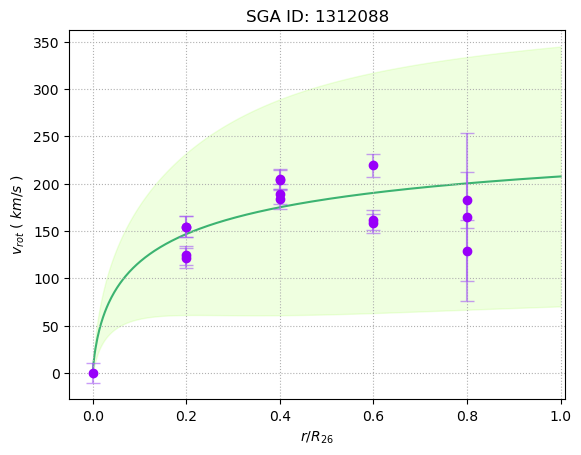

In [11]:
#--------------------------------------------------
# this is the old version fitting for 3 unknowns
#--------------------------------------------------


# def v_rot(r, v_max, r_turn, a):
#     return (v_max * r)/((r_turn**a + r**a)**(1/a))

# def chi2(params, v_data, v_err, r):
#     v_max, r_turn, a = params
#     v_model = (v_max * r)/((r_turn**a + r**a)**(1/a))
#     return np.sum(((v_data-v_model)/v_err)**2)


for i in np.unique(loa_rotvel['SGA_ID'])[:1]:

    sga_id = 1312088
    
    targ_id = loa_rotvel[loa_rotvel['SGA_ID'] == sga_id]

    # grab all fibers with velocity < 1000 km/s and passed VI
    valid_fibers = targ_id[(abs(targ_id['Velocity'])<1000) & (targ_id['bad_map']==0)]
    
    # grab radius
    r_kpc = valid_fibers['r_kpc']
    
    # make sure there are still 3 points to curve fit
    if (len(valid_fibers) < 3) or (len(np.unique(r_kpc.round(5))) < 3):
        continue

    # absolute velocities
    velocity = abs(valid_fibers['Velocity'])

    v_err = valid_fibers['V_err']

    # normalize r
    idx = np.argmax(velocity)

    r26_ratio = valid_fibers['DIST_R26']
    r26 = r_kpc[idx]/r26_ratio[idx]
    
#----------------------------------------------------------------------------
#create a pseudo-center fiber if there isn't one to assist with curve fitting
#----------------------------------------------------------------------------

    if np.all(r_kpc) != 0:
        z_cen_err = valid_fibers['Z_center'][0]
        velocity = np.append(velocity,0)
        r_kpc = np.append(r_kpc,0)
        v_err = np.append(v_err,c*z_cen_err)


#-----------------------------------------
# curve fitting
#-----------------------------------------
     
    # bounds for v max, r turn, and alpha
    bounds = [(0,1000),(0,np.max(r_kpc)),(0,100)]

    # initial guess for v max, r turn, and alpha
    initial_guess = [velocity[idx], r_kpc[idx], 1]

    #-------------
    # curve fit ----------------------------------
    #-------------
    min_fxn = minimize(fun = chi2, 
                 x0 = initial_guess, 
                 args = (velocity, v_err, r_kpc), 
                 bounds = bounds, 
                 method = 'Powell')
    #---------------------------------------------
    
    # vmax_fit, rturn_fit, alpha_fit
    min_fits = min_fxn.x
    
    #--------------------
    # get reduced chi 2 -------------------------------
    #--------------------
    chi2_fit= min_fxn.fun
    
    data_pts = len(velocity)
    
    reduced_chi2 = chi2_reduced(chi2_fit, data_pts)
    #------------------------------------------------
    
    

#-------------------------------
# uncertainty from curve fit
#-------------------------------
    
    hessian = ndt.Hessian(chi2)
    hess = hessian(min_fits,velocity, v_err, r_kpc)

    # get covariance matrix for errors
    # make empty matrix of nans to prevent from plotting
    try:
    #covariance matrix
        hess_inv = 2*np.linalg.inv(hess)
    # vmax_err, rturn_err, alpha_err
        fit_params_err = np.sqrt(np.diag(np.abs(hess_inv)))
    
    except LinAlgError:
        # Do an alternate to the above
        hess_inv = np.full((3,3),np.nan)

        
        
#----------------
# plot
#----------------
    fig = plt.figure()
    ax = fig.add_subplot()

    #---------------
    # curve fit -------------------------------------------
    #---------------
    r1 = np.linspace(0,r26,500)

    v_r = v_rot(r1,min_fits[0],min_fits[1],min_fits[2])
    #------------------------------------------------------

    # sample size
    size = 1000
    
    #------------------------------
    # uncertainty on curve fit   ---------------------------------------------------------------
    #------------------------------
    if ~np.isnan(hess_inv).any():
        samples=np.random.multivariate_normal(min_fits,hess_inv,size=size)

        # make sure all samples are positive
        good_samples = samples[(samples > 0).all(axis = 1)]
    
        # empty array for sample curve fit to go in
        v_sample = np.zeros((len(good_samples),500))
        
        # get curve fit for each sample distribution
        for i in range(len(good_samples)):
            indx = samples[i]
            v_x = v_rot(r1, indx[0], indx[1], indx[2])
            v_sample[i] = v_x
        
        #take standard deviation for all v_rot along each r
        std_dev = np.std(v_sample[~np.isnan(v_sample).any(axis=1)], axis = 0)

        # plot uncertainty
        ax.fill_between(r1/r26, v_r - std_dev, v_r + std_dev, alpha = .12, color = 'chartreuse')
        
        # plot curve fit
        ax.plot(r1/r26, v_r, color = 'mediumseagreen', zorder =1 )
        
    else:
        # plot curve fit
        ax.plot(r1/r26, v_r, color = 'mediumseagreen', zorder = 1)
        
        # note the covariance matrix returned NAN
        ax.annotate('invalid hessian', xy = (10,10), xycoords = 'figure pixels')
    #------------------------------------------------------------------------------------------------

    
    

    #------------------------------
    # v vs r points and errorbars -------------------------------------------------------------------------------------
    #------------------------------
    ax.errorbar(r_kpc/r26, velocity, yerr = v_err, ls = 'none', ecolor = 'xkcd:lighter purple', capsize = 5, zorder=2, alpha = .6)
    ax.scatter(r_kpc/r26, velocity, c = 'xkcd:vivid purple', zorder = 3)
    # ------------------------------------------------------------------------------------------------------------------
    
    ax.grid(ls=':')
    ax.set_title('SGA ID: {}'.format(sga_id))
    ax.set_xlim(None, 1.01)
    ax.set(xlabel='$r/R_{26}$', ylabel='$v_{rot}$ $($ $km/s$ $)$')

    
    
#-----------------------------------------  
# save everything to table or $PSCRATCH
#----------------------------------------- 
    
    # fig.savefig('/pscratch/sd/d/dbustos/curve_fit/' + 'sga_{}_curve_fit.png'.format(sga_id), dpi=120)
    
    # fig.clear()
    # plt.close(fig)
    
    # np.save('/pscratch/sd/d/dbustos/hessian/' + str(sga_id) + '_hessian.npy', hess)
    
    # table_idx = (loa_rotvel['SGA_ID'] == sga_id) & ((abs(loa_rotvel['Velocity']) < 1000)) & (loa_rotvel['bad_map']==0)
    # loa_rotvel['chi2_reduced'][table_idx] = reduced_chi2

    # loa_rotvel['vmax_fit'][table_idx] = min_fxn[0]
    # loa_rotvel['rturn_fit'][table_idx] = min_fxn[1]
    # loa_rotvel['alpha_fit'][table_idx] = min_fxn[2]
    
    # sanity check ---------------------------------
    print('sga_id:',str(sga_id))
    print('minimize fits (v, r, α): ', min_fits)
    print('fit_params_err (v, r, α): ', fit_params_err)
    print('reduced chi2: ', reduced_chi2)

/tmp/ipykernel_1857253/2449382737.py:5: RuntimeWarning: divide by zero encountered in scalar divide
  return chi2/dof
/tmp/ipykernel_1857253/237509766.py:117: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  samples=np.random.multivariate_normal(min_fits,hess_inv,size=size)
/tmp/ipykernel_1857253/4036978402.py:2: RuntimeWarning: invalid value encountered in scalar power
  return (v_max * r)/((r_turn**a + r**a)**(1/a))
/tmp/ipykernel_1857253/4036978402.py:2: RuntimeWarning: divide by zero encountered in power
  return (v_max * r)/((r_turn**a + r**a)**(1/a))
/tmp/ipykernel_1857253/4036978402.py:2: RuntimeWarning: invalid value encountered in divide
  return (v_max * r)/((r_turn**a + r**a)**(1/a))
/tmp/ipykernel_1857253/4036978402.py:2: RuntimeWarning: overflow encountered in power
  return (v_max * r)/((r_turn**a + r**a)**(1/a))
/tmp/ipykernel_1857253/4036978402.py:2: RuntimeWarning: divide by zero encountered in power
  return (v_max * r)/((r_turn**a + r**a)**(1/a))


sga_id: 425
minimize fits (v, r, α):  [85.82930027 22.21381265  0.85594571]
fit_params_err (v, r, α):  [541.32247258 149.04551764   5.16476312]
reduced chi2:  inf
sga_id: 7880
minimize fits (v, r, α):  [125.2955882    2.74711222  99.99999973]
fit_params_err (v, r, α):  [1.24214229e+01 1.32814801e-01 2.02409088e+02]
reduced chi2:  14.086368614398753
sga_id: 12657
minimize fits (v, r, α):  [175.05773629  22.90991336  76.83466828]
fit_params_err (v, r, α):  [10.27110793  0.70293508 76.15717877]
reduced chi2:  inf


/tmp/ipykernel_1857253/237509766.py:117: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  samples=np.random.multivariate_normal(min_fits,hess_inv,size=size)
/tmp/ipykernel_1857253/4036978402.py:2: RuntimeWarning: divide by zero encountered in power
  return (v_max * r)/((r_turn**a + r**a)**(1/a))
/tmp/ipykernel_1857253/4036978402.py:2: RuntimeWarning: invalid value encountered in divide
  return (v_max * r)/((r_turn**a + r**a)**(1/a))
/tmp/ipykernel_1857253/4036978402.py:2: RuntimeWarning: overflow encountered in power
  return (v_max * r)/((r_turn**a + r**a)**(1/a))
/tmp/ipykernel_1857253/4036978402.py:2: RuntimeWarning: overflow encountered in scalar power
  return (v_max * r)/((r_turn**a + r**a)**(1/a))
/tmp/ipykernel_1857253/3517407738.py:3: RuntimeWarning: invalid value encountered in divide
  v_model = (v_max * r)/((r_turn**a + r**a)**(1/a))
/tmp/ipykernel_1857253/237509766.py:117: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  samples=np

sga_id: 31124
minimize fits (v, r, α):  [264.74033707   0.92043853   0.42358699]
fit_params_err (v, r, α):  [2588.41391081    5.06923768    3.64048983]
reduced chi2:  3.0021094292271773
sga_id: 36792
minimize fits (v, r, α):  [217.09556412   2.49728765   1.26575676]
fit_params_err (v, r, α):  [168.06571186   1.52866766   1.70862126]
reduced chi2:  0.09344434817186392


/tmp/ipykernel_1857253/237509766.py:117: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  samples=np.random.multivariate_normal(min_fits,hess_inv,size=size)
/tmp/ipykernel_1857253/4036978402.py:2: RuntimeWarning: divide by zero encountered in power
  return (v_max * r)/((r_turn**a + r**a)**(1/a))
/tmp/ipykernel_1857253/4036978402.py:2: RuntimeWarning: invalid value encountered in divide
  return (v_max * r)/((r_turn**a + r**a)**(1/a))
/tmp/ipykernel_1857253/4036978402.py:2: RuntimeWarning: invalid value encountered in scalar power
  return (v_max * r)/((r_turn**a + r**a)**(1/a))
/tmp/ipykernel_1857253/3517407738.py:3: RuntimeWarning: invalid value encountered in divide
  v_model = (v_max * r)/((r_turn**a + r**a)**(1/a))
/tmp/ipykernel_1857253/237509766.py:117: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  samples=np.random.multivariate_normal(min_fits,hess_inv,size=size)
/tmp/ipykernel_1857253/4036978402.py:2: RuntimeWarning: divide by zero en

sga_id: 37670
minimize fits (v, r, α):  [57.11152142 15.61207386 28.59200512]
fit_params_err (v, r, α):  [ 6.72808021  1.3073603  27.74339191]
reduced chi2:  9.594408418843443


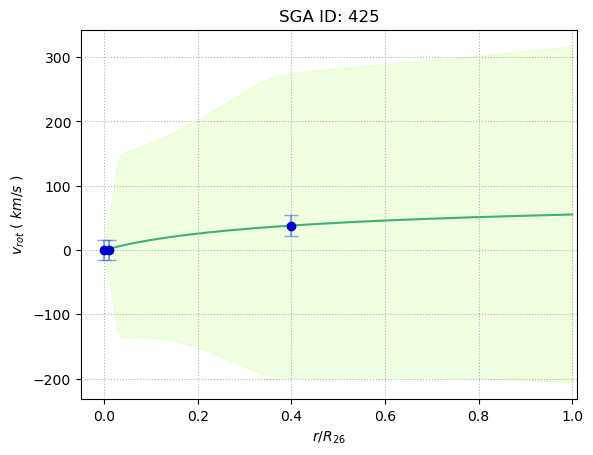

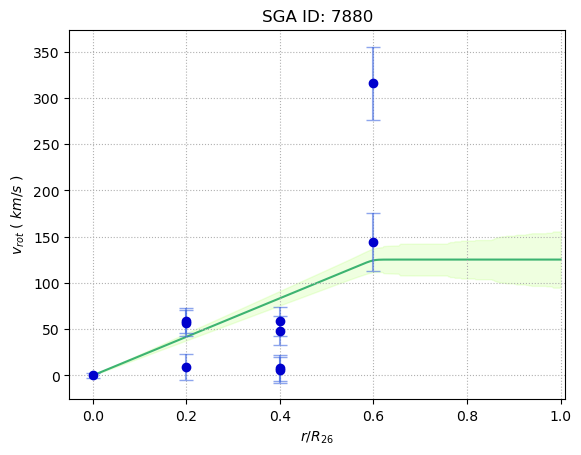

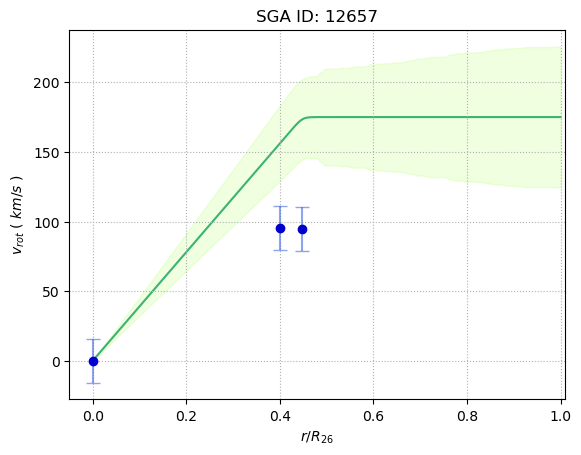

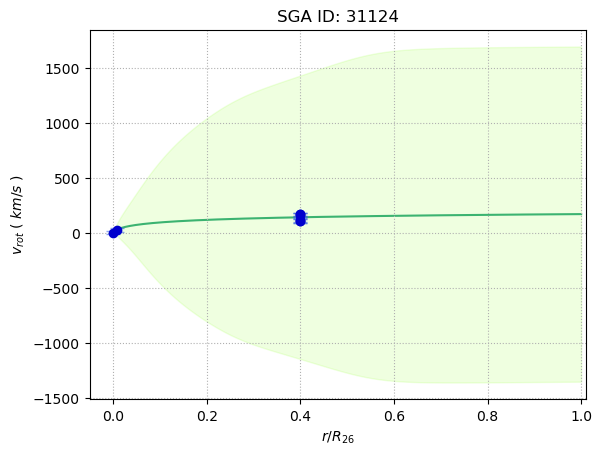

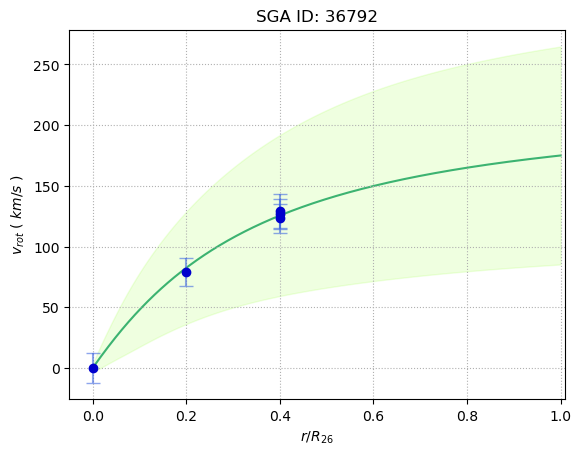

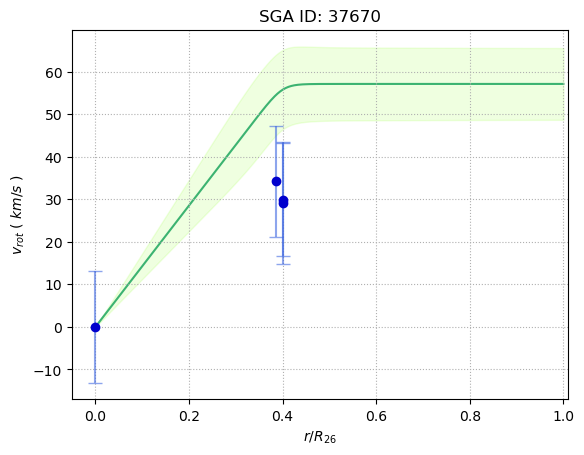

In [223]:
for i in np.unique(loa_rotvel['SGA_ID'])[:20]:

    sga_id = i
    
    targ_id = loa_rotvel[loa_rotvel['SGA_ID'] == sga_id]

    # grab all fibers with velocity < 1000 km/s and passed VI
    valid_fibers = targ_id[(abs(targ_id['Velocity'])<1000) & (targ_id['bad_map']==0)]
    
    # grab radius
    r_kpc = valid_fibers['r_kpc']
    
    # make sure there are still 3 points to curve fit
    if (len(valid_fibers) < 3) or (len(np.unique(r_kpc.round(5))) < 3):
        continue

    # absolute velocities
    velocity = abs(valid_fibers['Velocity'])

    v_err = valid_fibers['V_err']

    # index for max velocity for initial guess
    idx = np.argmax(velocity)

    r26_ratio = valid_fibers['DIST_R26']
    r26 = r_kpc[idx]/r26_ratio[idx]
    
#----------------------------------------------------------------------------
#create a pseudo-center fiber if there isn't one to assist with curve fitting
#----------------------------------------------------------------------------

    if np.all(r_kpc) != 0:
        z_cen_err = valid_fibers['Z_center'][0]
        velocity = np.append(velocity,0)
        r_kpc = np.append(r_kpc,0)
        v_err = np.append(v_err,c*z_cen_err)

        

#-----------------------------------------
# curve fitting
#-----------------------------------------
     
    # bounds for v max, r turn, and alpha
    bounds = [(0,1000),(0,np.max(r_kpc)),(0,100)]

    # initial guess for v max, r turn, and alpha
    initial_guess = [velocity[idx], r_kpc[idx], 1]

    #-------------
    # curve fit ----------------------------------
    #-------------
    min_fxn = minimize(fun = chi2, 
                 x0 = initial_guess, 
                 args = (velocity, v_err, r_kpc), 
                 bounds = bounds, 
                 method = 'Powell')
    #---------------------------------------------
    
    # vmax_fit, rturn_fit, alpha_fit
    min_fits = min_fxn.x
    
    #--------------------
    # get reduced chi 2 -------------------------------
    #--------------------
    chi2_fit= min_fxn.fun
    
    data_pts = len(velocity)
    
    reduced_chi2 = chi2_reduced(chi2_fit, data_pts)
    #------------------------------------------------
    
    

#-------------------------------
# uncertainty from curve fit
#-------------------------------
    
    hessian = ndt.Hessian(chi2)
    hess = hessian(min_fits,velocity, v_err, r_kpc)

    # get covariance matrix for errors
    # make empty matrix of nans to prevent from plotting
    try:
    #covariance matrix
        hess_inv = 2*np.linalg.inv(hess)
    # vmax_err, rturn_err, alpha_err
        fit_params_err = np.sqrt(np.diag(np.abs(hess_inv)))
    
    except LinAlgError:
        # Do an alternate to the above
        hess_inv = np.full((3,3),np.nan)

        
        
#----------------
# plot
#----------------
    fig = plt.figure()
    ax = fig.add_subplot()

    #---------------
    # curve fit -------------------------------------------
    #---------------
    r1 = np.linspace(0,r26,500)

    v_r = v_rot(r1,min_fits[0],min_fits[1],min_fits[2])
    #------------------------------------------------------

    # sample size
    size = 1000
    
    #------------------------------
    # uncertainty on curve fit   ---------------------------------------------------------------
    #------------------------------
    if ~np.isnan(hess_inv).any():
        samples=np.random.multivariate_normal(min_fits,hess_inv,size=size)

        # make sure all samples are positive
        good_samples = samples[(samples > 0).all(axis = 1)]
    
        # empty array for sample curve fit to go in
        v_sample = np.zeros((len(good_samples),500))
        
        # get curve fit for each sample distribution
        for i in range(len(good_samples)):
            indx = samples[i]
            v_x = v_rot(r1, indx[0], indx[1], indx[2])
            v_sample[i] = v_x
        
        #take standard deviation for all v_rot along each r
        std_dev = np.std(v_sample[~np.isnan(v_sample).any(axis=1)], axis = 0)

        # plot uncertainty
        ax.fill_between(r1/r26, v_r - std_dev, v_r + std_dev, alpha = .12, color = 'chartreuse')
        
        # plot curve fit
        ax.plot(r1/r26, v_r, color = 'mediumseagreen', zorder =1 )
        
    else:
        # plot curve fit
        ax.plot(r1/r26, v_r, color = 'mediumseagreen', zorder = 1)
        
        # note the covariance matrix returned NAN
        ax.annotate('invalid hessian', xy = (10,10), xycoords = 'figure pixels')
    #------------------------------------------------------------------------------------------------

    
    

    #------------------------------
    # v vs r points and errorbars -------------------------------------------------------------------------------------
    #------------------------------
    ax.errorbar(r_kpc/r26, velocity, yerr = v_err, ls = 'none', ecolor = 'royalblue', capsize = 5, zorder=2, alpha = .6)
    ax.scatter(r_kpc/r26, velocity, c = 'mediumblue', zorder = 3)
    # ------------------------------------------------------------------------------------------------------------------
    
    ax.grid(ls=':')
    ax.set_title('SGA ID: {}'.format(sga_id))
    ax.set_xlim(None, 1.01)
    ax.set(xlabel='$r/R_{26}$', ylabel='$v_{rot}$ $($ $km/s$ $)$')

    
    
#-----------------------------------------  
# save everything to table or $PSCRATCH
#----------------------------------------- 
    
    # fig.savefig('/pscratch/sd/d/dbustos/curve_fit/' + 'sga_{}_curve_fit.png'.format(sga_id), dpi=120)
    
    # fig.clear()
    # plt.close(fig)
    
    # np.save('/pscratch/sd/d/dbustos/hessian/' + str(sga_id) + '_hessian.npy', hess)
    
    # table_idx = (loa_rotvel['SGA_ID'] == sga_id) & ((abs(loa_rotvel['Velocity']) < 1000)) & (loa_rotvel['bad_map']==0)
    # loa_rotvel['chi2_reduced'][table_idx] = reduced_chi2

    # loa_rotvel['vmax_fit'][table_idx] = min_fxn[0]
    # loa_rotvel['rturn_fit'][table_idx] = min_fxn[1]
    # loa_rotvel['alpha_fit'][table_idx] = min_fxn[2]
    
    # sanity check ---------------------------------
    print('sga_id:',str(sga_id))
    print('minimize fits (v, r, α): ', min_fits)
    print('fit_params_err (v, r, α): ', fit_params_err)
    print('reduced chi2: ', reduced_chi2)

minimize fits (v, r, α):  [2.89364905e+02 8.10901034e-02 5.00960444e-01]
fit_params_err (v, r, α):  [292.42876941   0.41796578   1.03545696]
reduced chi2:  4.860387771239126


/tmp/ipykernel_1857253/3902484159.py:104: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  samples=np.random.multivariate_normal(min_fits,hess_inv,size=size)
/tmp/ipykernel_1857253/4036978402.py:2: RuntimeWarning: invalid value encountered in scalar power
  return (v_max * r)/((r_turn**a + r**a)**(1/a))
/tmp/ipykernel_1857253/4036978402.py:2: RuntimeWarning: divide by zero encountered in power
  return (v_max * r)/((r_turn**a + r**a)**(1/a))


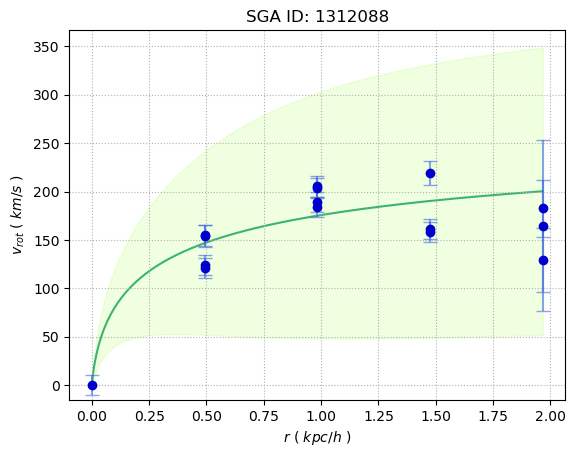

In [169]:
for i in np.unique(loa_rotvel['SGA_ID'])[:1]:

    sga_id = 1312088
    
    targ_id = loa_rotvel[loa_rotvel['SGA_ID'] == sga_id]

    # grab all fibers with velocity < 1000 km/s and passed VI
    valid_fibers = targ_id[(abs(targ_id['Velocity'])<1000) & (targ_id['bad_map']==0)]
    
    # grab radius
    r_kpc = valid_fibers['r_kpc']
    
    # make sure there are still 3 points to curve fit
    if (len(valid_fibers) < 3) or (len(np.unique(r_kpc.round(5))) < 3):
        continue

    # absolute velocities
    velocity = abs(valid_fibers['Velocity'])

    v_err = valid_fibers['V_err']
    
#----------------------------------------------------------------------------
#create a pseudo-center fiber if there isn't one to assist with curve fitting
#----------------------------------------------------------------------------

    if np.all(r_kpc) != 0:
        z_cen_err = valid_fibers['Z_center'][0]
        velocity = np.append(velocity,0)
        r_kpc = np.append(r_kpc,0)
        v_err = np.append(v_err,c*z_cen_err)

        

#-----------------------------------------
# curve fitting
#-----------------------------------------
    
    # index for max velocity for initial guess
    idx = np.argmax(velocity)

    # bounds for v max, r turn, and alpha
    bounds = [(0,1000),(0,np.max(r_kpc)),(0,100)]

    # initial guess for v max, r turn, and alpha
    initial_guess = [velocity[idx], r_kpc[idx], 1]

    #-------------
    # curve fit ----------------------------------
    #-------------
    min_fxn = minimize(fun = chi2, 
                 x0 = initial_guess, 
                 args = (velocity, v_err, r_kpc), 
                 bounds = bounds, 
                 method = 'Powell')
    #---------------------------------------------
    
    # vmax_fit, rturn_fit, alpha_fit
    min_fits = min_fxn.x
    
    #--------------------
    # get reduced chi 2 -------------------------------
    #--------------------
    chi2_fit= min_fxn.fun
    
    data_pts = len(velocity)
    
    reduced_chi2 = chi2_reduced(chi2_fit, data_pts)
    #------------------------------------------------
    
    

#-------------------------------
# uncertainty from curve fit
#-------------------------------
    
    hessian = ndt.Hessian(chi2)
    hess = hessian(min_fits,velocity, v_err, r_kpc)

    # get covariance matrix for errors
    # make empty matrix of nans to prevent from plotting
    try:
    #covariance matrix
        hess_inv = 2*np.linalg.inv(hess)
    # vmax_err, rturn_err, alpha_err
        fit_params_err = np.sqrt(np.diag(np.abs(hess_inv)))
    
    except LinAlgError:
        # Do an alternate to the above
        hess_inv = np.full((3,3),np.nan)

        
        
#----------------
# plot
#----------------
    fig = plt.figure()
    ax = fig.add_subplot()

    #---------------
    # curve fit -------------------------------------------
    #---------------
    r1 = np.linspace(0,np.max(r_kpc),500)

    v_r = v_rot(r1,min_fits[0],min_fits[1],min_fits[2])
    #------------------------------------------------------

    # sample size
    size = 1000
    
    #------------------------------
    # uncertainty on curve fit   ---------------------------------------------------------------
    #------------------------------
    if ~np.isnan(hess_inv).any():
        samples=np.random.multivariate_normal(min_fits,hess_inv,size=size)

        # make sure all samples are positive
        good_samples = samples[(samples > 0).all(axis = 1)]
    
        # empty array for sample curve fit to go in
        v_sample = np.zeros((len(good_samples),500))
        
        # get curve fit for each sample distribution
        for i in range(len(good_samples)):
            indx = samples[i]
            v_x = v_rot(r1, indx[0], indx[1], indx[2])
            v_sample[i] = v_x
        
        #take standard deviation for all v_rot along each r
        std_dev = np.std(v_sample[~np.isnan(v_sample).any(axis=1)], axis = 0)

        # plot uncertainty
        ax.fill_between(r1, v_r - std_dev, v_r + std_dev, alpha = .12, color = 'chartreuse')
        
        # plot curve fit
        ax.plot(r1, v_r, color = 'mediumseagreen', zorder =1 )
        
    else:
        # plot curve fit
        ax.plot(r1, v_r, color = 'mediumseagreen', zorder = 1)
        
        # note the covariance matrix returned NAN
        ax.annotate('invalid hessian', xy = (10,10), xycoords = 'figure pixels')
    #------------------------------------------------------------------------------------------------

    
    

    #------------------------------
    # v vs r points and errorbars -------------------------------------------------------------------------------------
    #------------------------------
    ax.errorbar(r_kpc, velocity, yerr = v_err, ls = 'none', ecolor = 'royalblue', capsize = 5, zorder=2, alpha = .6)
    ax.scatter(r_kpc, velocity, c = 'mediumblue', zorder = 3)
    # ------------------------------------------------------------------------------------------------------------------
    
    ax.grid(ls=':')
    ax.set_title('SGA ID: {}'.format(sga_id))
    ax.set_ylim(-15, None)
    ax.set(xlabel='$r$ $($ $kpc/h$ $)$', ylabel='$v_{rot}$ $($ $km/s$ $)$')

    
    
#-----------------------------------------  
# save everything to table or $PSCRATCH
#----------------------------------------- 
    
    # fig.savefig('/pscratch/sd/d/dbustos/curve_fit/' + 'sga_{}_curve_fit.png'.format(sga_id), dpi=120)
    
    # fig.clear()
    # plt.close(fig)
    
    # np.save('/pscratch/sd/d/dbustos/hessian/' + str(sga_id) + '_hessian.npy', hess)
    
    # table_idx = (loa_rotvel['SGA_ID'] == sga_id) & ((abs(loa_rotvel['Velocity']) < 1000)) & (loa_rotvel['bad_map']==0)
    # loa_rotvel['chi2_reduced'][table_idx] = reduced_chi2

    # loa_rotvel['vmax_fit'][table_idx] = min_fxn[0]
    # loa_rotvel['rturn_fit'][table_idx] = min_fxn[1]
    # loa_rotvel['alpha_fit'][table_idx] = min_fxn[2]
    
    # sanity check ---------------------------------
    print('sga_id:',str(sga_id))
    print('minimize fits (v, r, α): ', min_fits)
    print('fit_params_err (v, r, α): ', fit_params_err)
    print('reduced chi2: ', reduced_chi2)

minimize fits =  [2.89364905e+02 8.10901034e-02 5.00960444e-01]
fit_params_err =  [292.42876941   0.41796578   1.03545696]


/tmp/ipykernel_1160457/2607072621.py:61: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  samples=np.random.multivariate_normal(min_fits,hess_inv,size=size)
/tmp/ipykernel_1160457/4036978402.py:2: RuntimeWarning: invalid value encountered in scalar power
  return (v_max * r)/((r_turn**a + r**a)**(1/a))
/tmp/ipykernel_1160457/4036978402.py:2: RuntimeWarning: divide by zero encountered in power
  return (v_max * r)/((r_turn**a + r**a)**(1/a))


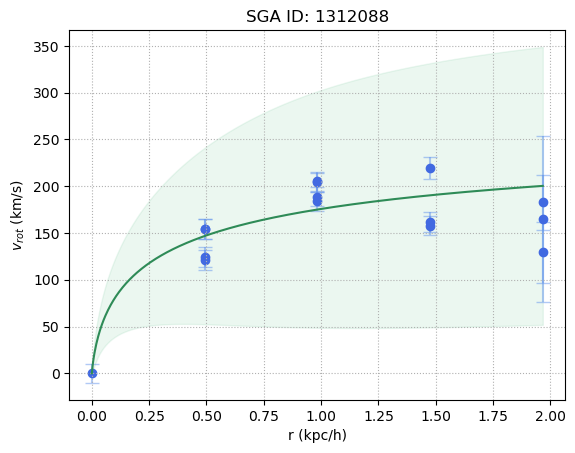

In [45]:
for i in np.unique(loa_rotvel['SGA_ID'])[:1]:

    sga_id = 1312088
    
    targ_id = loa_rotvel[loa_rotvel['SGA_ID'] == sga_id]

    valid_fibers = targ_id[(targ_id['Velocity']<1000) & (targ_id['bad_map']==0)]

    if len(valid_fibers) < 3:
        continue

    r_kpc = valid_fibers['r_kpc']
    
    #absolute velocities
    velocity = abs(valid_fibers['Velocity'])

    v_err = valid_fibers['V_err']

    #create a pseudo-center fiber if there isn't one to assist with curve fitting
    if np.all(r_kpc) != 0:
        z_cen_err = valid_fibers['Z_center'][0]
        velocity = np.append(velocity,0)
        r_kpc = np.append(r_kpc,0)
        v_err = np.append(v_err,c*z_cen_err)

    #index for max velocity for initial guess
    idx = np.argmax(velocity)

    #bounds for v max, r turn, and alpha
    bounds = [(0,1000),(0,np.max(r_kpc)),(0,100)]

    #initial guess for v max, r turn, and alpha
    initial_guess = [velocity[idx], r_kpc[idx], 1]

    #minimize fxn
    min_fxn = minimize(fun = chi2, 
                 x0 = initial_guess, 
                 args = (velocity, v_err, r_kpc), 
                 bounds = bounds, 
                 method = 'Powell')
    
    # vmax_fit, rturn_fit, alpha_fit
    min_fits = min_fxn.x

    hessian = ndt.Hessian(chi2)
    hess = hessian(min_fits,velocity, v_err, r_kpc)

    # try:
    #covariance matrix
    hess_inv = 2*np.linalg.inv(hess)
    # vmax_err, rturn_err, alpha_err
    fit_params_err = np.sqrt(np.diag(np.abs(hess_inv)))
    # except LinAlgError:
        # Do an alternate to the above

    print('minimize fits = ', min_fits)
    print('fit_params_err = ', fit_params_err)

    size = 1000

    samples=np.random.multivariate_normal(min_fits,hess_inv,size=size)
    
    good_samples = samples[(samples > 0).all(axis = 1)]
    
    r1 = np.linspace(0,np.max(r_kpc),500)

    v_r = v_rot(r1,min_fits[0],min_fits[1],min_fits[2])

    v_sample = np.zeros((len(good_samples),500))
    
    # get v_rot for each sample distribution
    for i in range(len(good_samples)):
        indx = samples[i]
        v_x = v_rot(r1, indx[0], indx[1], indx[2])
        v_sample[i] = v_x

    # print(v_sample)
    # print(~np.isnan(v_sample).any(axis=1))
    
    #take standard deviation for all v_rot along r
    std_dev = np.std(v_sample[~np.isnan(v_sample).any(axis=1)], axis = 0)
    
    fig = plt.figure()
    ax = fig.add_subplot()

    ax.grid(ls=':')

    ax.fill_between(r1, v_r - std_dev, v_r + std_dev, alpha = .1, color = 'mediumseagreen')
    
    ax.plot(r1, v_r, color = 'seagreen')
    ax.errorbar(r_kpc, velocity, yerr = v_err, ls = 'none', ecolor = 'cornflowerblue', capsize = 5, zorder=1,alpha = .5)
    ax.scatter(r_kpc, velocity, c = 'royalblue')
    
    ax.set_title('SGA ID: {}'.format(sga_id))
    ax.set(xlabel='r (kpc/h)', ylabel='$v_{rot}$ (km/s)')

 message: Optimization terminated successfully.
 success: True
  status: 0
     fun: 58.32465325486951
       x: [ 2.894e+02  8.109e-02  5.010e-01]
     nit: 10
   direc: [[-3.224e+01 -3.990e-01 -4.988e-02]
           [ 4.122e+00 -1.462e-03 -9.816e-04]
           [-7.626e+00 -2.108e-02 -1.410e-02]]
    nfev: 462
      V_err       
------------------
10.298161926674412
10.384004050235493
 10.43574827418646
 32.65766447223178
10.526319461583018
11.109785211141851
 10.39006842433978
10.458613207663717
 88.40743142872842
 10.26893004041665
10.537393553215532
29.341869682310378
10.421359304469132
12.124322447104483
10.770139193269992


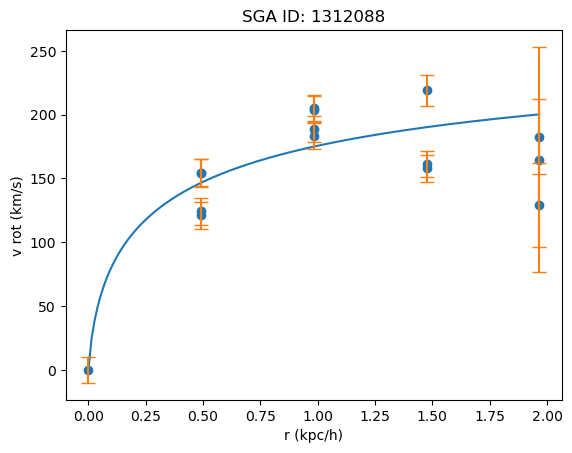

In [44]:
for i in np.unique(loa_rotvel['SGA_ID'])[:1]:

    sga_id = 1312088
    
    targ_id = loa_rotvel[loa_rotvel['SGA_ID'] == sga_id]

    valid_fibers = targ_id[(targ_id['Velocity']<1000) & (targ_id['bad_map']==0)]

    if len(valid_fibers) < 3:
        continue

    #r = valid_fibers['DIST_R26']
    r_kpc = valid_fibers['r_kpc']
    
    #absolute velocities
    velocity = abs(valid_fibers['Velocity'])

    v_err = valid_fibers['V_err']

    #index for max velocity for initial guess
    idx = np.argmax(velocity)

    #bounds for v max, r turn, and alpha
    bounds = [(0,1000),(0,np.max(r_kpc)),(0,100)]

    #initial guess for v max, r turn, and alpha
    initial_guess = [velocity[idx], r_kpc[idx], 1]

    #minimize fxn
    min_fxn = minimize(fun = chi2, 
                 x0 = initial_guess, 
                 args = (velocity, v_err, r_kpc), 
                 bounds = bounds, 
                 method = 'Powell')
    
    vmax_fit, rturn_fit, alpha_fit = min_fxn.x
    print(min_fxn)

    # print(vmax_fit,rturn_fit,alpha_fit)
    # print(v_rot(r_kpc,vmax_fit, rturn_fit, alpha_fit))

    r1 = np.linspace(0,np.max(r_kpc),len(r_kpc)*10)

    v_r = v_rot(r1,vmax_fit, rturn_fit, alpha_fit)

    fig = plt.figure()
    ax = fig.add_subplot()
    ax.scatter(r_kpc, velocity)
    ax.plot(r1,v_r)

    
    #ax.plot(r_kpc,v_rot(r_kpc,vmax_fit, rturn_fit, alpha_fit))
    ax.errorbar(r_kpc, velocity, yerr = v_err, ls='none', capsize=5)
    print(v_err)
    
    ax.set_title('SGA ID: {}'.format(sga_id))
    ax.set(xlabel='r (kpc/h)', ylabel='v rot (km/s)')